In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\trans_conc\Export.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1365 entries, 0 to 1364
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  1365 non-null   str  
 1   Message  1365 non-null   str  
 2   Status   1365 non-null   str  
dtypes: str(3)
memory usage: 32.1 KB


In [15]:
aux=pd.DataFrame()
aux=raw_data
aux['Headers']='NaN'

for i in range(0,aux.shape[0]):
    aux.iloc[i,3]=aux.iloc[i,2][0:8]

aux['Headers'].value_counts()

Headers
0x252513    1317
0x252501      20
0x252511      17
0x252514      11
Name: count, dtype: int64

In [16]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1365 entries, 0 to 1364
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  1365 non-null   str  
 1   Message  1365 non-null   str  
 2   Status   1365 non-null   str  
 3   Headers  1365 non-null   str  
dtypes: str(4)
memory usage: 42.8 KB


Odometer

In [17]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
odometer=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Odometer in meters']=odometer
unit_aux['Date']=date
unit_aux['Raw data']=raw

#print(unit_aux['Odometer in meters'])

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 1328 entries, 0 to 1364
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Created             1328 non-null   str  
 1   Message             1328 non-null   str  
 2   Status              1328 non-null   str  
 3   Headers             1328 non-null   str  
 4   Odometer in meters  1328 non-null   int64
 5   Date                1328 non-null   str  
 6   Raw data            1328 non-null   str  
dtypes: int64(1), str(6)
memory usage: 83.0 KB
None


260720010719 -> 0 -> 2132536.0 -> 0x25251300591F370869487067435056003C38402D000000335E00000007000020000000FFFFFFFFFFFFFFFFFFFF00D500208A38002607200107199A995543A9CF96C29D7D14410000007403941250FFFFFF0000200000FFFFFF
260720050720 -> 1 -> 2132536.0 -> 0x25251300591F380869487067435056003C38402D000000335F00000007000020000000FFFFFFFFFFFFFFFFFFFF00D500208A38002607200507209A995543A9CF96C29D7D14410000007403941249FFFFFF00001E0000FFFFFF
260720090720 -> 2 -> 2132536.0 -> 0x25251300591F390869487067435056003C38402D000000305C00000007000020000000FFFFFFFFFFFFFFFFFFFF00D500208A38002607200907209A995543A9CF96C29D7D14410000007403941247FFFFFF00001D0000FFFFFF
260720130720 -> 3 -> 2132536.0 -> 0x25251300591F3A0869487067435056003C38402D000000335D00000007000020000000FFFFFFFFFFFFFFFFFFFF00D500208A38002607201307209A995543A9CF96C29D7D14410000007403941247FFFFFF00001C0000FFFFFF
260720134625 -> 4 -> 2132536.0 -> 0x252514005901190869487067435056003C38402D000000335800000007000061000000FFFFFFFFFFFFFFFFFFFF16D500208A3800

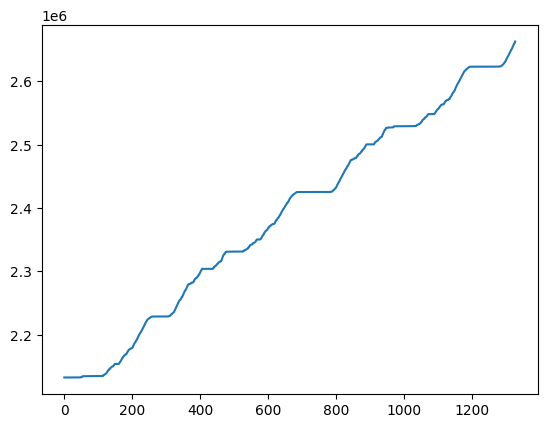

In [18]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,4]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])
    raw_data_.append(unit.iloc[i,6])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

for i in range(0,len(odometer)):
    print(date[i],'->',x_axis[i],'->',y_axis[i],'->',raw_data_[i])

#print(odometer[len(odometer)-1]-odometer[0])
plt.plot(x_axis,y_axis)

Speed

In [19]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
speed=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    speed.append(int(unit_aux.iloc[i,2][142:145]))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Speed']=speed
unit_aux['Raw data']=raw
unit_aux['Date']=date

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 1328 entries, 0 to 1364
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Created             1328 non-null   str    
 1   Message             1328 non-null   str    
 2   Status              1328 non-null   str    
 3   Headers             1328 non-null   str    
 4   Odometer in meters  1328 non-null   float64
 5   Speed               1328 non-null   int64  
 6   Raw data            1328 non-null   str    
 7   Date                1328 non-null   str    
dtypes: float64(1), int64(1), str(6)
memory usage: 93.4 KB
None


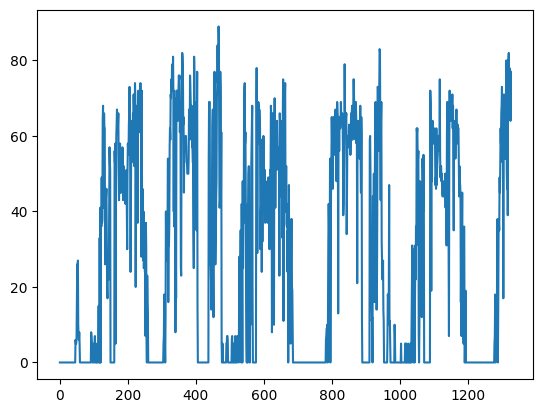

In [20]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,5]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])
    raw_data_.append(unit.iloc[i,4])

plt.plot(x_axis,y_axis)

Satellites

In [21]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 128)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)

for i in range(0,unit.shape[0]):
    if unit.iloc[i,5]>0:
        num_events=num_events+1
        print(unit.iloc[i,5],'->', unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

128 -> 2026-07-21 12:00:51.953 -> 31 -> 0x25251300591FB40869487067435056003C38402D00000037DF00000007000061000000FFFFFFFFFFFFFFFFFFFF00D50020BB0B0026072112004866E63E438EA796C2721815410620006103931365FFFFFF0000210000FFFFFF
128 -> 2026-07-21 12:46:27.310 -> 31 -> 0x25251300591FE60869487067435056003C38402D00000014DF00000007000061000000FFFFFFFFFFFFFFFFFFFF00D500211AFA0026072112461000806E43E16796C252C116410510003D03931363FFFFFF0000260000FFFFFF
128 -> 2026-07-21 15:27:33.913 -> 31 -> 0x2525130059208C0869487067435056003C38402D00000014DF00000007000061000000FFFFFFFFFFFFFFFFFFFF00D50022896D0026072115254833331843170396C2043E16410760011E03941365FFFFFF00002A0000FFFFFF
128 -> 2026-07-21 15:27:34.093 -> 31 -> 0x2525130059208D0869487067435056003C38402D00000011DF00000007000061000000FFFFFFFFFFFFFFFFFFFF008000228E7D002607211526479A190943A90896C2924F16410750012D03941368FFFFFF00002A0000FFFFFF
128 -> 2026-07-21 15:27:34.223 -> 31 -> 0x2525130059208E0869487067435056003C38402D00000022DF00000007000061000000FFFF

In/Outs

In [22]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]
in_outs=[]

#unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    aux_raw_data.append(aux_cad[i])
    in_outs.append(bin (int (aux_cad[i][64:68],16) ))      

unit_=pd.DataFrame()
unit_['in and outs']=in_outs
unit_['date']=aux_date
unit_['raw data']=aux_raw_data

in_outs_df=unit_.sort_values('date',ascending=True)

#in_outs_df.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\in_outs.csv')

<class 'pandas.DataFrame'>
Index: 1328 entries, 0 to 1019
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  1328 non-null   str  
 1   Message  1328 non-null   str  
 2   Status   1328 non-null   str  
 3   Headers  1328 non-null   str  
dtypes: str(4)
memory usage: 51.9 KB


Power

In [23]:
ext_bat_13=raw_data[raw_data['Status'].str.contains('0x252513')]
ext_bat_14=raw_data[raw_data['Status'].str.contains('0x252514')]
ext_bat_vol=pd.concat([ext_bat_13,ext_bat_14])
ext_bat=[]
date_bat=[]
bat_df=pd.DataFrame()

ext_bat_vol.info()

for i in range(0,ext_bat_vol.shape[0]):
    val=(float(ext_bat_vol.iloc[i,2][154:158]))/100
    date_bat.append(ext_bat_vol.iloc[i,2][106:119])
    ext_bat.append(val)
#print(ext_bat)

for i in range(0,ext_bat_vol.shape[0]):
    if ext_bat[i]<3:
        bat_df['Date']=date_bat
        bat_df['int_bat']=ext_bat

print(bat_df)

<class 'pandas.DataFrame'>
Index: 1328 entries, 0 to 1019
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  1328 non-null   str  
 1   Message  1328 non-null   str  
 2   Status   1328 non-null   str  
 3   Headers  1328 non-null   str  
dtypes: str(4)
memory usage: 51.9 KB
Empty DataFrame
Columns: []
Index: []


Pánico

In [24]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]

unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    #aux_raw_data.append(aux_cad[i])
    if aux_value=='03':
        print(aux_value, ' -> ',aux_date[i])    

print("len aux_cad: ",len(aux_cad))

<class 'pandas.DataFrame'>
Index: 1328 entries, 0 to 1019
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  1328 non-null   str  
 1   Message  1328 non-null   str  
 2   Status   1328 non-null   str  
 3   Headers  1328 non-null   str  
dtypes: str(4)
memory usage: 51.9 KB
len aux_cad:  1328
